In [ ]:
# (c) 2026 Spectral Forge Labs. All rights reserved. 
# Use of this source code is governed by the Spectral Forge EULA.

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

class BrownianMotionTradingEnv(gym.Env):
    """
    A Reinforcement Learning environment where an agent trades based on
    a price driven by Brownian motion.
    The agent can 'buy', 'hold', or 'sell' at each step, aiming for profit.
    """
    metadata = {'render_modes': ['human', 'none'], 'render_fps': 30}

    def __init__(self,
                 num_steps=100,
                 time_total=1.0,
                 initial_price=100.0,
                 volatility=0.1,  # Sigma for the Brownian motion
                 drift=0.05,
                 transaction_cost_pct=0.01, # 0.1% transaction cost
                 starting_cash=1000.0,
                 max_shares=10,
                 lookback_window=30,
                 phi=0,
                 df=15,
                 render_mode=None):

        super().__init__()

        # --- Environment Parameters ---
        self.num_steps = num_steps
        self.time_total = time_total
        self.initial_price = initial_price
        self.volatility = volatility
        self.drift = drift
        self.transaction_cost_pct = transaction_cost_pct
        self.starting_cash = starting_cash
        self.max_shares = max_shares
        self.render_mode = render_mode
        self.lookback_window = lookback_window
        self.peak_price = 0.0
        self.phi = phi 
        self.df = df # Degrees of freedom for Kurtosis
        self.base_volatility = volatility

        self.action_history = []

        # Calculate dt for Brownian motion
        self.dt = self.time_total / self.num_steps

        # --- Action Space ---
        # 0: Hold
        # 1: Buy 1 share
        # 2: Sell 1 share
        self.action_space = spaces.Discrete(3)

        # --- Observation Space ---
       # We define the number of features: 3 (metadata) + 30 (history)
        obs_size = 3 + self.lookback_window
        
        # Update low and high bounds to match the new size
        # Using -np.inf and np.inf for the price history window
        self.observation_space = spaces.Box(
            low=-np.inf, 
            high=np.inf, 
            shape=(obs_size,), 
            dtype=np.float32
        )

        # --- Internal State (will be initialized in reset) ---
        self.current_step = 0
        self.current_price = 0.0
        self.cash = 0.0
        self.shares = 0
        self.price_history = []
        self.cash_history = []
        self.shares_history = []
        self.portfolio_value_history = [] # For rendering/tracking

        # For rendering
        self.fig = None
        self.ax = None


    def _generate_brownian_path(self):
        """
        Generates a 1D Geometric Brownian motion path with 
        Autocorrelation (AR(1)) and Kurtosis (Student's t-distribution).
        """
        # 1. Use Student's t-distribution for Kurtosis (Fat Tails)
        # df=self.df (e.g., 5) creates fatter tails than a normal distribution
        shocks = np.random.standard_t(df=self.df, size=self.num_steps) 
        
        # 2. Add Autocorrelation (AR(1) logic)
        autocorr_shocks = np.zeros(self.num_steps)
        # Initialize the first shock
        autocorr_shocks[0] = shocks[0]
        
        for t in range(1, self.num_steps):
            # Current shock is influenced by the previous one based on self.phi
            autocorr_shocks[t] = self.phi * autocorr_shocks[t-1] + shocks[t]
            
        # 3. Final Path Calculation (Geometric Brownian Motion style)
        # (mu - 0.5 * sigma^2) * dt
        drift_component = (self.drift - 0.5 * self.volatility**2) * self.dt
        
        # Combine drift and the auto-correlated stochastic component
        # S_t+dt = S_t * exp(drift_component + volatility * sqrt(dt) * Z_t)
        log_returns = drift_component + (self.volatility * np.sqrt(self.dt) * autocorr_shocks)

        # Initialize path with initial price
        # Using cumsum on log_returns provides a vectorized way to build the GBM path
        # We prepend a 0 to the cumsum to ensure the first price is exactly self.initial_price
        path = self.initial_price * np.exp(np.insert(np.cumsum(log_returns), 0, 0.0))

        # Safeguard: Ensure price doesn't go below a tiny positive value
        path[path < 1e-9] = 1e-9
        
        return path

    def _get_obs(self):
        # 1. Handle Price History and Padding
        prices = list(self.price_history)
        if len(prices) < self.lookback_window:
            # Use initial_price for padding to maintain scale consistency
            padding = [self.initial_price] * (self.lookback_window - len(prices))
            prices = padding + prices
        
        # Get the most recent window
        recent_prices = np.array(prices[-self.lookback_window:], dtype=np.float32)
        
        # 2. Normalize Prices (Relative to Current Price)
        # This turns [100, 101, 99] into [0.0, 0.01, -0.01] roughly
        # It allows the agent to see "Percent change" rather than "Raw Price"
        norm_prices = (recent_prices / self.current_price) - 1.0 
        
        # 3. Normalize Account Metadata
        # Scale everything relative to starting capital or max limits
        norm_cash = self.cash / self.starting_cash
        norm_shares = self.shares / self.max_shares
        
        current_portfolio_value = self.cash + (self.shares * self.current_price)
        norm_portfolio = current_portfolio_value / self.starting_cash
        
        # 4. Package Metadata
        metadata = np.array([
            norm_cash,
            norm_shares,
            norm_portfolio
        ], dtype=np.float32)
        
        # 5. Concatenate: [Cash, Shares, Value, Price_t-29, ... Price_t-0]
        return np.concatenate([metadata, norm_prices])

    def _get_info(self):
        """Returns auxiliary information for debugging/logging."""
        return {
            "current_price": self.current_price,
            "cash": self.cash,
            "shares": self.shares,
            "portfolio_value": self.cash + self.shares * self.current_price
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = 0
        self.cash = self.starting_cash 
        self.shares = 0 
        self.peak_price = self.initial_price
        self.brownian_path = self._generate_brownian_path()
        self.current_price = self.brownian_path[self.current_step]

        # Randomize the regime: Momentum (>0) or Reversion (<0)
        # 50% of the time, give it a trending market to practice 'riding the wave'
        # 50% of the time, give it a mean-reverting market to practice 'timing the exit'
        if np.random.rand() > 0.5:
            self.phi = np.random.uniform(0.1, 0.5)
        else:
            self.phi = np.random.uniform(-0.5, -0.1)
        
        # Optional: Randomize volatility too for extra generalization
        #self.volatility = np.random.uniform(0.02, 0.15) 

        self.action_history = [] # Clear history for the new episode
        self.price_history = [self.initial_price]

        self.current_step = 0
        self.peak_price = self.initial_price
        
        # This now uses the randomized phi and df
        self.brownian_path = self._generate_brownian_path()
        self.current_price = self.brownian_path[self.current_step]

        # 1. Pad PRICE history for the observation window
        self.price_history = [self.current_price] * self.lookback_window
        
        # 2. Pad PORTFOLIO history to match the length of price_history
        # This prevents the Matplotlib dimension mismatch error
        initial_value = self.cash + (self.shares * self.current_price)
        self.portfolio_value_history = [initial_value] * self.lookback_window

        # 3. Keep these as single-entry or pad them if your render uses them
        self.cash_history = [self.cash] * self.lookback_window
        self.shares_history = [self.shares] * self.lookback_window

        observation = self._get_obs()
        info = self._get_info()

        if self.render_mode == 'human':
            self._render_frame()

        return observation, info

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action {action}"

        # 1. Capture state BEFORE price move and action
        prev_price = self.current_price
        prev_portfolio_value = self.cash + self.shares * prev_price

        # 2. Execute Action & Calculate Immediate Transaction Friction
        # We penalize the act of trading slightly to prevent "spamming" buy/sell
        friction_penalty = 0.0
        if action == 1:  # Buy
            if self.shares < self.max_shares:
                cost = self.current_price * (1 + self.transaction_cost_pct)
                self.cash -= cost
                self.shares += 1
                friction_penalty = self.current_price * self.transaction_cost_pct
            else:
                friction_penalty = 0.05  # Higher penalty for trying to exceed limits
                
        elif action == 2:  # Sell
            if self.shares > 0:
                revenue = self.current_price * (1 - self.transaction_cost_pct)
                self.cash += revenue
                self.shares -= 1
                friction_penalty = self.current_price * self.transaction_cost_pct
            else:
                friction_penalty = 0.05

        # 3. Advance Time and Update Price
        self.current_step += 1
        if self.current_step < len(self.brownian_path):
            self.current_price = self.brownian_path[self.current_step]
        
        # --- NEW: Trailing Stop Loss Logic ---
        # 1. Update the High-Water Mark if we are in a long position
        if self.shares > 0:
            self.peak_price = max(self.peak_price, self.current_price)
        else:
            # Reset peak price when flat or short to prepare for next trade
            self.peak_price = self.current_price

        # 2. Calculate the "Drawdown" from the peak
        trailing_stop_penalty = 0.0
        if self.shares > 0:
            drop_from_peak = (self.peak_price - self.current_price) / self.peak_price
            
            # If price drops more than 2% from its peak while we hold shares
            if drop_from_peak > 0.02:
                # Penalty scales with how far past the stop we are
                trailing_stop_penalty = (drop_from_peak ** 2) * 100.0

        # 4. CALCULATE NEW REWARD LOGIC
        # A. Price Movement Reward: Captures the profit/loss of the current position
        price_delta = self.current_price - prev_price
        # This rewards positive delta if long (shares > 0) and negative delta if short (shares < 0)
        movement_reward = self.shares * price_delta

        # B. Time Decay / Opportunity Cost (The "Swing Trader" Incentive)
        # Penalize holding a position that isn't moving to encourage finding better entry points
        # Updated B. Time Decay / Opportunity Cost
        idle_penalty = 0.0
        if self.shares == 0:
            idle_penalty = 0.005 # Small penalty for not being in the market
        elif action == 0 and self.shares != 0:
            idle_penalty = 0.001 * abs(self.shares)

        # C. Final Reward Composition
        # We subtract friction to ensure the trade was worth the cost
        reward = movement_reward - friction_penalty - idle_penalty - trailing_stop_penalty

        # 5. Check Termination
        terminated = self.current_step >= len(self.brownian_path) - 1
        truncated = False

        # 6. Final State Calculations
        current_portfolio_value = self.cash + self.shares * self.current_price
        
        # Update histories and return
        self.price_history.append(self.current_price)
        self.cash_history.append(self.cash)
        self.shares_history.append(self.shares)
        self.portfolio_value_history.append(current_portfolio_value)

        return self._get_obs(), reward, terminated, truncated, self._get_info()

    def render(self):
        """Renders the environment."""
        if self.render_mode == 'human':
            self._render_frame()

    def _render_frame(self):
        if self.fig is None:
            plt.ion() 
            # 3 Panes: Price/Actions, Returns %, and Inventory
            self.fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
            self.ax = [ax1, ax2, ax3]
            plt.tight_layout(pad=3.0)

        # 1. Clear previous frames
        for ax in self.ax:
            ax.clear()
            ax.grid(True, alpha=0.3)
        
        time_steps = np.arange(len(self.price_history))

        # --- Pane 1: Price Action & Agent Decisions ---
        self.ax[0].plot(time_steps, self.price_history, label='Price', color='blue', alpha=0.6)
        
        # Identify Buy/Sell actions for markers
        # Assuming Action 1 = Buy, Action 2 = Sell (adjust based on your actual action space)
        buys = [i for i, a in enumerate(self.action_history) if a == 1]
        sells = [i for i, a in enumerate(self.action_history) if a == 2]
        
        if buys:
            self.ax[0].scatter(buys, [self.price_history[i] for i in buys], 
                               marker='^', color='green', label='Buy', zorder=5)
        if sells:
            self.ax[0].scatter(sells, [self.price_history[i] for i in sells], 
                               marker='v', color='red', label='Sell', zorder=5)
            
        self.ax[0].set_title(f"Episode Analysis | Phi: {self.phi:.2f} | Vol: {self.volatility:.2f}")
        self.ax[0].set_ylabel("Price ($)")
        self.ax[0].legend(loc='upper left')

        # --- Pane 2: Portfolio Performance (Normalized %) ---
        if len(self.portfolio_value_history) > 0:
            initial_val = self.portfolio_value_history[0]
            returns = [(v - initial_val) / initial_val * 100 for v in self.portfolio_value_history]
            
            self.ax[1].plot(time_steps, returns, color='green', label='Net Return %')
            self.ax[1].axhline(0, color='black', lw=1, ls='--')
            
            # Dynamic scaling for returns
            r_min, r_max = min(returns), max(returns)
            self.ax[1].set_ylim(r_min - 0.5, r_max + 0.5)
            
        self.ax[1].set_ylabel("Return (%)")
        self.ax[1].legend(loc='upper left')

        # --- Pane 3: Inventory Level ---
        self.ax[2].fill_between(time_steps, self.shares_history, color='purple', alpha=0.3, label='Shares')
        self.ax[2].set_ylabel("Shares Held")
        self.ax[2].set_xlabel("Time Step")
        self.ax[2].set_ylim(0, max(self.shares_history) + 1 if self.shares_history else 11)
        self.ax[2].set_xlim(0, self.num_steps)

        # Refresh canvas
        self.fig.canvas.draw_idle()
        self.fig.canvas.flush_events()


--- Initial Environment State ---
Initial Observation: [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Initial Info: {'current_price': 100.0, 'cash': 10000, 'shares': 0, 'portfolio_value': 10000.0}
---------------------------------

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting Training Loop...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -39.1    |
| time/              |          |
|    fps             | 4404     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -18         |
| time/                   |             |
|    fps                  | 2939        |
|

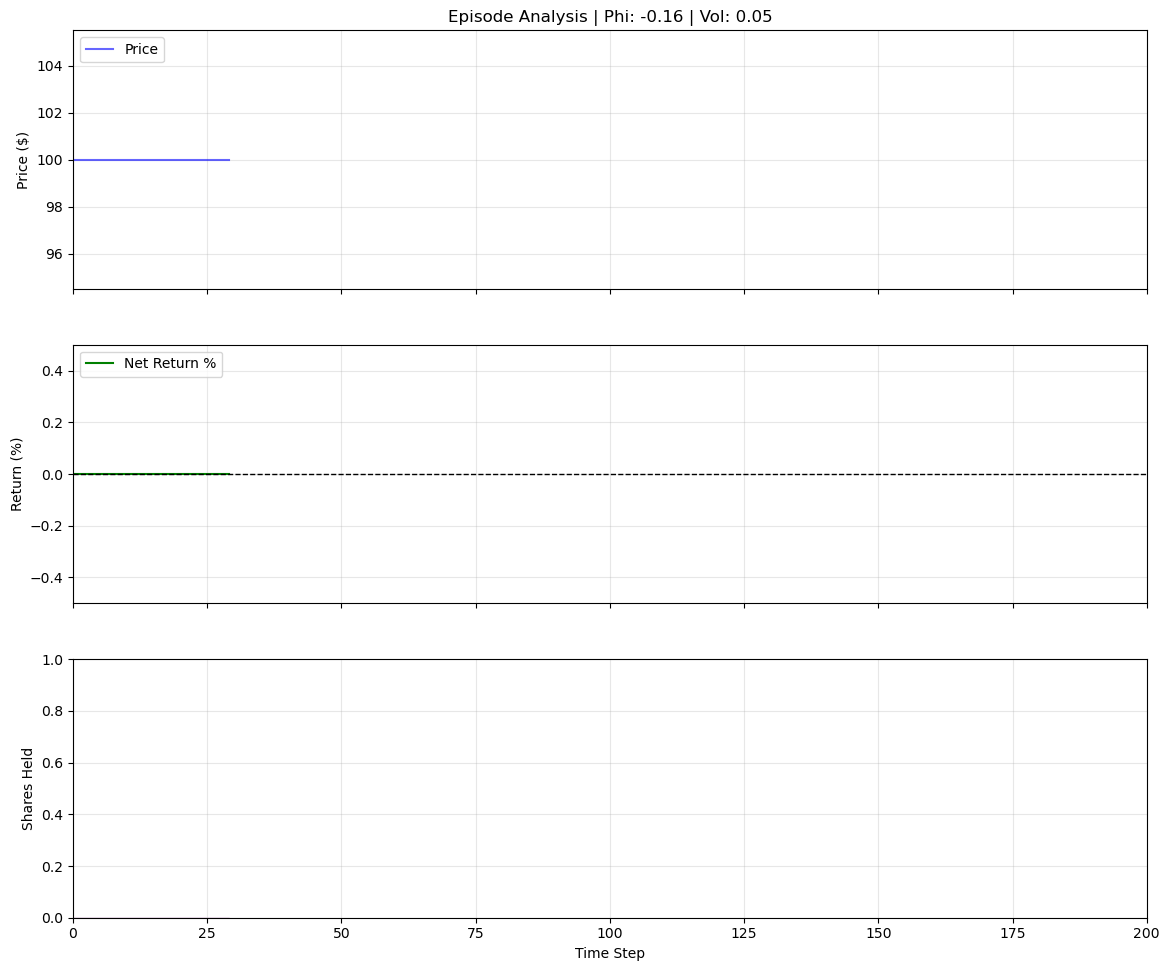

In [27]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
import matplotlib.pyplot as plt

# --- 1. Setup Environment Variables ---
# You can easily adjust these parameters here
env_kwargs = {
    "num_steps": 200,
    "time_total": 1.0,
    "initial_price": 100.0,
    "volatility": 0.05,
    "transaction_cost_pct": 0,
    "drift": 0,
    "max_shares": 10,
    "starting_cash": 10000, # Increased for better visibility
}

if __name__ == "__main__":
    # --- 2. Initialize Environments ---
    # Training env (no rendering)
    env = BrownianMotionTradingEnv(**env_kwargs, render_mode=None)
    # Evaluation env (for the callback to check performance)
    eval_env = BrownianMotionTradingEnv(**env_kwargs, render_mode=None)

    # Print Initial State Info as requested
    obs, info = env.reset()
    print("--- Initial Environment State ---")
    print("Initial Observation:", obs) # [Price, Cash, Shares, Portfolio]
    print("Initial Info:", info)
    print("---------------------------------\n")

    # --- 3. Define Model and Callbacks ---
    # Increased ent_coef to force the agent to stop holding 0 shares
    # --- 3. Define Model and Callbacks ---
    model = PPO(
        "MlpPolicy", 
        env, 
        verbose=1, 
        device='cpu',
        n_steps=2048,          # Number of steps to run for each environment per update
        batch_size=64,         # Minibatch size for each gradient update
        gamma=0.99,            # Discount factor (0.99 is standard for long-term rewards)
        ent_coef=0.01,         # Keeps the agent exploring
        learning_rate=0.0003   # Standard starting rate for PPO
    )

    # Stop training when mean reward hits 50
    callback_on_best = StopTrainingOnRewardThreshold(reward_threshold=50, verbose=1)
    eval_callback = EvalCallback(eval_env, 
                                 callback_on_new_best=callback_on_best, 
                                 verbose=1, 
                                 eval_freq=100000,
                                 best_model_save_path="./logs/")

    # --- 4. Train the Agent ---
    print("Starting Training Loop...")
    model.learn(total_timesteps=1000000, callback=eval_callback)

    # --- 5. Final Detailed Testing (Post-Training) ---
    print("\n--- Testing Trained Agent (Detailed Info) ---")
    # Use 'human' mode here to see the plot from image_98b393.png
    env_test = BrownianMotionTradingEnv(**env_kwargs, render_mode='human')
    obs, info = env_test.reset()
    
    total_reward = 0
    for step in range(env_test.num_steps):
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_test.step(action)
        total_reward += reward
        
        # Optional: Print detailed step info to see Cash and Shares changing
        if step % 50 == 0:
             print(f"Step {step}: Price={info['current_price']:.2f}, "
                   f"Cash={info['cash']:.2f}, Shares={info['shares']}, "
                   f"Portfolio={info['portfolio_value']:.2f}")

        if terminated or truncated:
            break

    print(f"\nFinal Test Episode Finished.")
    print(f"Total Reward: {total_reward:.2f}")
    print("Final Info:", info) # Now you see final Cash/Shares/Portfolio
    
    # Keep the plot open
    if env_test.render_mode == 'human':
        plt.ioff()
        plt.show()

    env_test.close()